In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('movies.csv')

# Cleaning the data
df['runtime_num'] = df['runtime'].str.extract(r'(\d+)').astype(float)
df['votes_num'] = df['votes'].str.replace(',', '', regex=False).astype(float)
df['gross_num'] = df['gross_earn'].str.replace('$', '', regex=False).str.replace('M', '', regex=False).astype(float)

clean_data = df[['runtime_num', 'votes_num', 'gross_num', 'rating']].dropna()

X = clean_data[['runtime_num', 'votes_num', 'gross_num']]
y = clean_data['rating']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [14]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 0.62
RMSE: 0.80


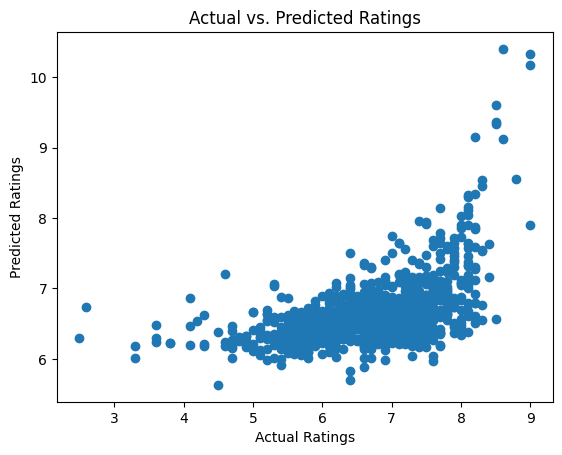

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs. Predicted Ratings")
plt.show()

Phase 2 : Classification

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [20]:


df = pd.read_csv('movies.csv')
df = df.dropna(subset=['gross_earn', 'genre'])

df['runtime_num'] = df['runtime'].str.extract(r'(\d+)').astype(float)
df['votes_num'] = df['votes'].str.replace(',', '', regex=False).astype(float)
df['gross_num'] = df['gross_earn'].str.replace('$', '', regex=False).str.replace('M', '', regex=False).astype(float)

genre_encoded = df['genre'].str.get_dummies(sep=', ')

In [21]:
df['good_movie'] = (df['rating'] >= 7.0).astype(int)

In [22]:
X = pd.concat([df[['runtime_num', 'votes_num', 'gross_num']], genre_encoded], axis=1)
y = df['good_movie']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Accuracy : 0.81
Precision : 0.79
Recall : 0.71
F1 Score: 0.75



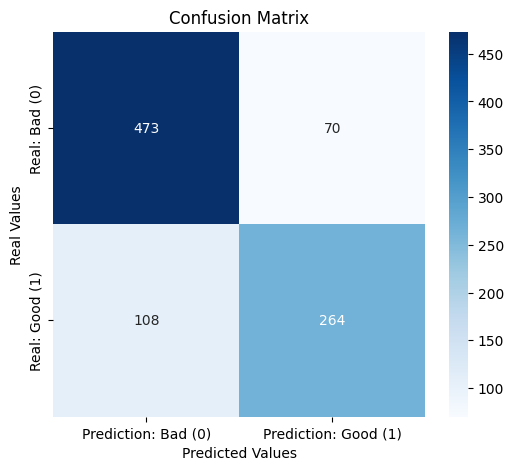

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = model.predict(X_test_scaled)


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall : {recall:.2f}")
print(f"F1 Score: {f1:.2f}\n")


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediction: Bad (0)', 'Prediction: Good (1)'],
            yticklabels=['Real: Bad (0)', 'Real: Good (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Real Values')
plt.xlabel('Predicted Values')
plt.show()

Phase 3 : Decision Tree, KNN, Cross-Validation

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn_model = KNeighborsClassifier(n_neighbors=5)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [28]:
knn_scores = cross_val_score(knn_model, X_scaled, y, cv=5)
tree_scores = cross_val_score(tree_model, X_scaled, y, cv=5)


print(f"KNN Accuracy: {knn_scores.mean():.4f}")
print(f"Decision Tree Accuracy: {tree_scores.mean():.4f}")

KNN Accuracy: 0.7018
Decision Tree Accuracy: 0.5802
